In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP's JS visualization (needed for notebook plots)
shap.initjs()

/Users/vaishnavikolli/Desktop/Project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load models
xgb_model = joblib.load('../models/xgboost_model.pkl')
lr_model  = joblib.load('../models/logistic_regression.pkl')
scaler    = joblib.load('../models/scaler.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

# Load test data
X_test = pd.read_csv('../data/X_test.csv')
y_test = pd.read_csv('../data/y_test.csv').squeeze()

X_test_scaled = scaler.transform(X_test)

print(f"Test set shape: {X_test.shape}")
print(f"Features: {feature_names}")

Test set shape: (1407, 19)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [3]:
# TreeExplainer is the right one for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(f"SHAP values shape: {shap_values_xgb.shape}")
# Should be (1408, 19) — one SHAP value per feature per row

SHAP values shape: (1407, 19)


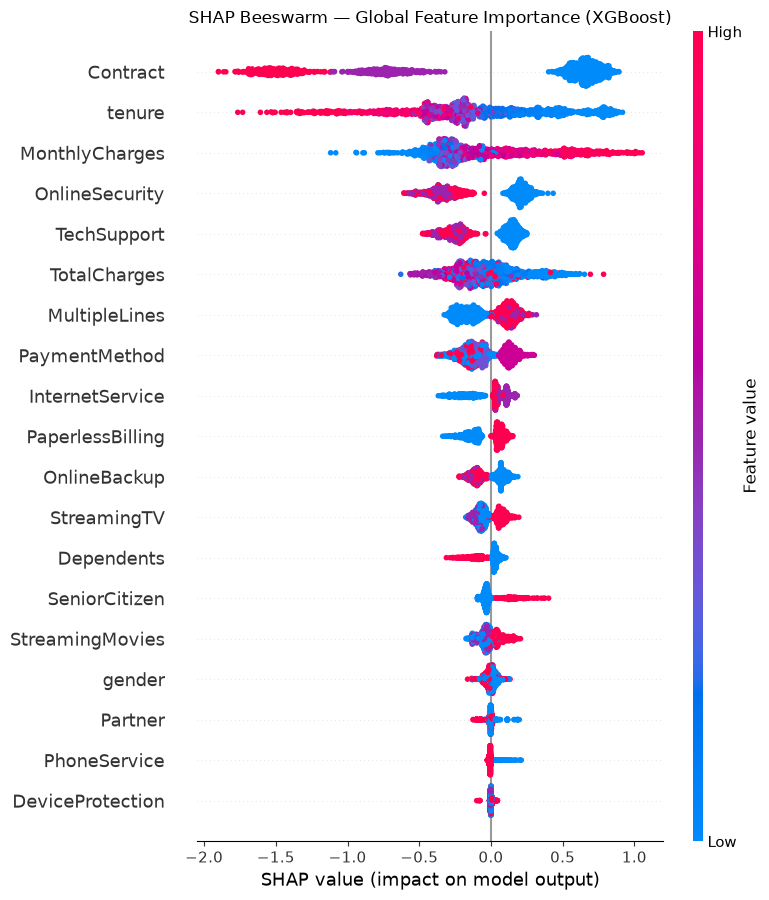

In [4]:
# This is your most important global plot
# Each dot = one customer, color = feature value, x-axis = impact on prediction

plt.figure()
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Beeswarm — Global Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig('../data/shap_beeswarm_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

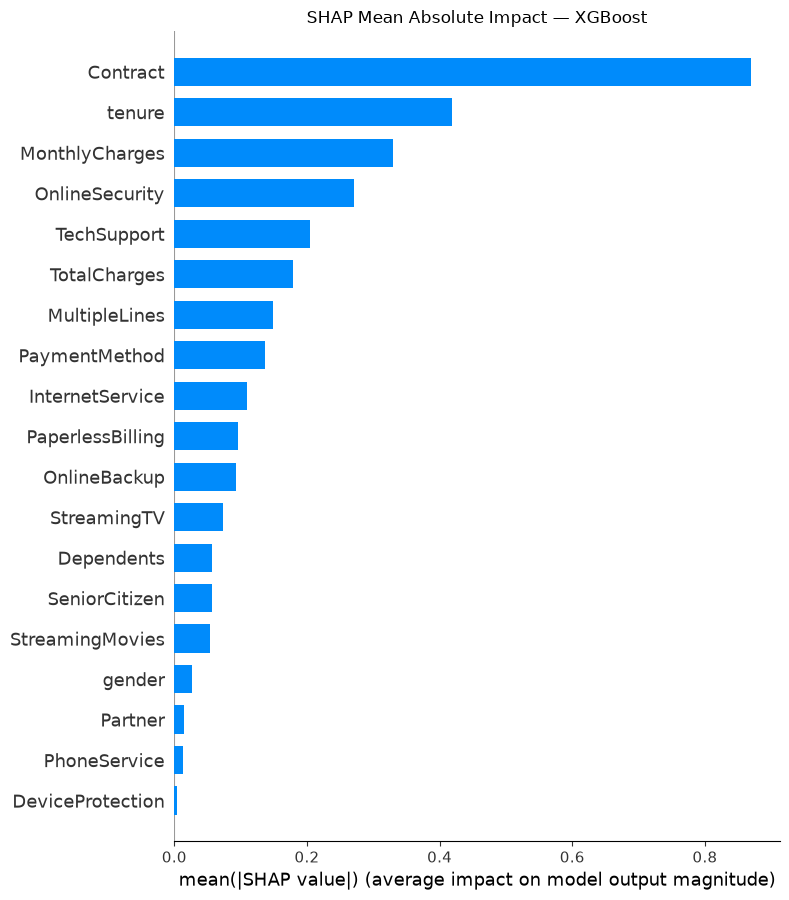

In [5]:
plt.figure()
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Mean Absolute Impact — XGBoost")
plt.tight_layout()
plt.savefig('../data/shap_bar_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Pick a mix: some churners, some not
churn_indices    = y_test[y_test == 1].index[:3].tolist()
no_churn_indices = y_test[y_test == 0].index[:2].tolist()
sample_indices   = churn_indices + no_churn_indices

print("Sample customer indices:", sample_indices)
print("Their actual labels:", y_test.loc[sample_indices].tolist())

Sample customer indices: [3, 5, 8, 0, 1]
Their actual labels: [1, 1, 1, 0, 0]



Customer 3 | Actual: Churn | Predicted: No Churn | Churn Probability: 11.37%


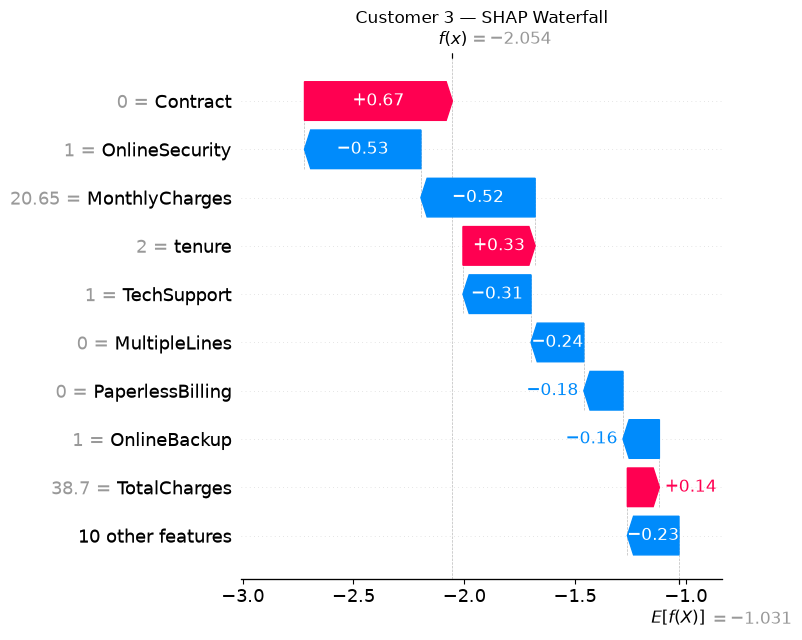


Customer 5 | Actual: Churn | Predicted: Churn | Churn Probability: 52.47%


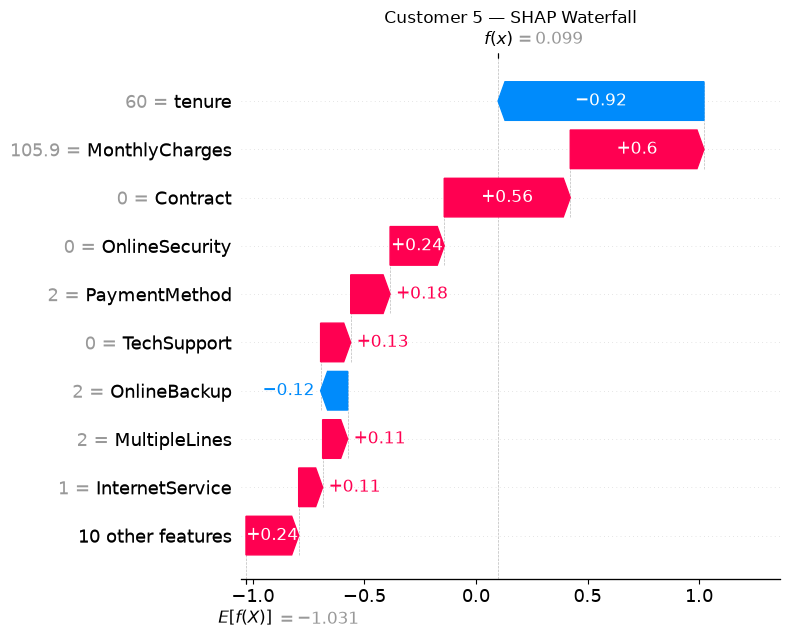


Customer 8 | Actual: Churn | Predicted: Churn | Churn Probability: 64.37%


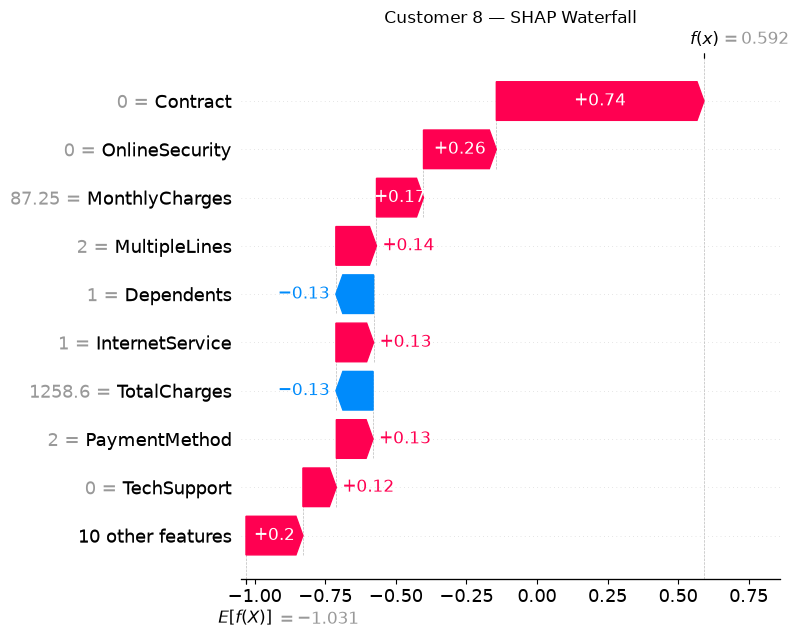


Customer 0 | Actual: No Churn | Predicted: No Churn | Churn Probability: 1.02%


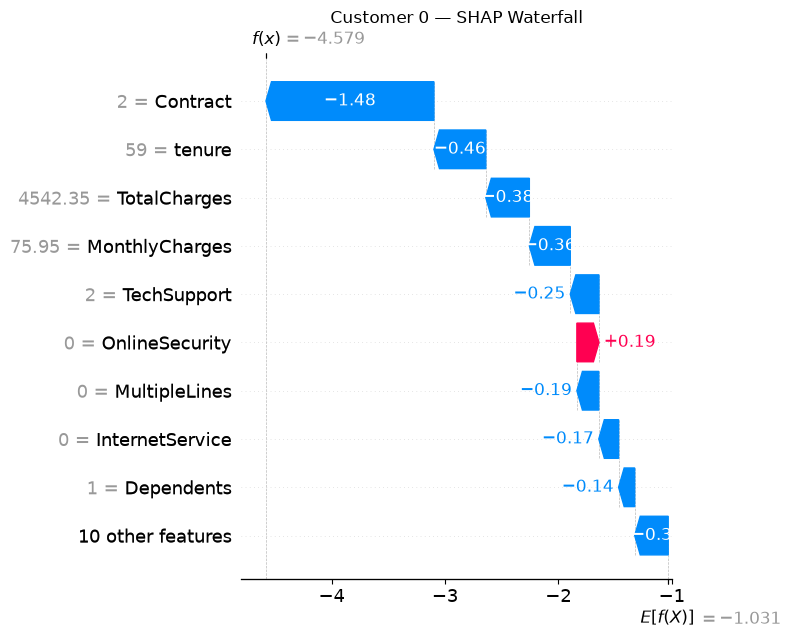


Customer 1 | Actual: No Churn | Predicted: Churn | Churn Probability: 75.35%


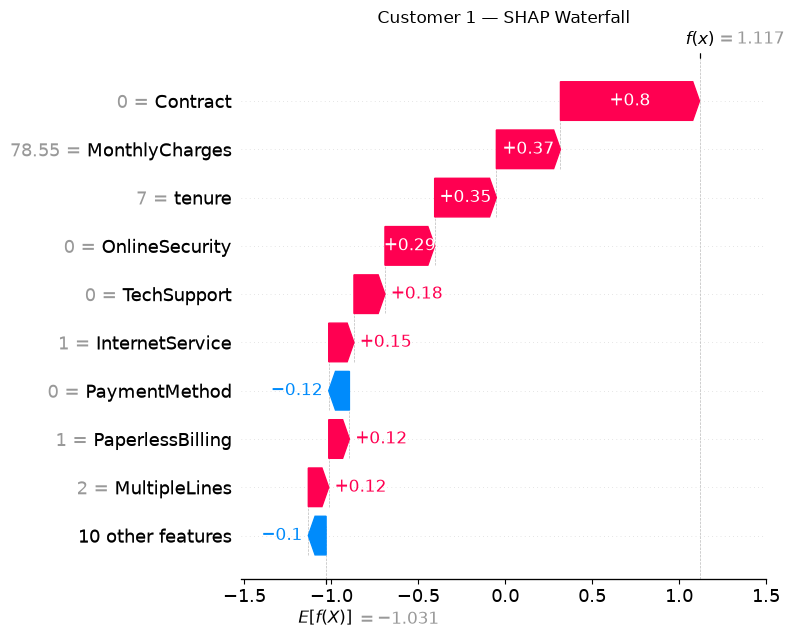

In [7]:
for idx in sample_indices:
    # Get position in X_test (not original index)
    pos = X_test.index.get_loc(idx)
    
    actual    = y_test.loc[idx]
    predicted = xgb_model.predict(X_test.loc[[idx]])[0]
    prob      = xgb_model.predict_proba(X_test.loc[[idx]])[0][1]
    
    print(f"\nCustomer {idx} | Actual: {'Churn' if actual else 'No Churn'} | "
          f"Predicted: {'Churn' if predicted else 'No Churn'} | "
          f"Churn Probability: {prob:.2%}")
    
    # Waterfall plot
    shap_explanation = shap.Explanation(
        values        = shap_values_xgb[pos],
        base_values   = explainer_xgb.expected_value,
        data          = X_test.iloc[pos].values,
        feature_names = feature_names
    )
    
    plt.figure()
    shap.waterfall_plot(shap_explanation, show=False)
    plt.title(f"Customer {idx} — SHAP Waterfall")
    plt.tight_layout()
    plt.savefig(f'../data/shap_waterfall_{idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [8]:
explainer_lr     = shap.LinearExplainer(lr_model, X_test_scaled)
shap_values_lr   = explainer_lr.shap_values(X_test_scaled)

print(f"LR SHAP values shape: {shap_values_lr.shape}")

Background dataset has 1407 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1407 when initializing the masker.


LR SHAP values shape: (1407, 19)


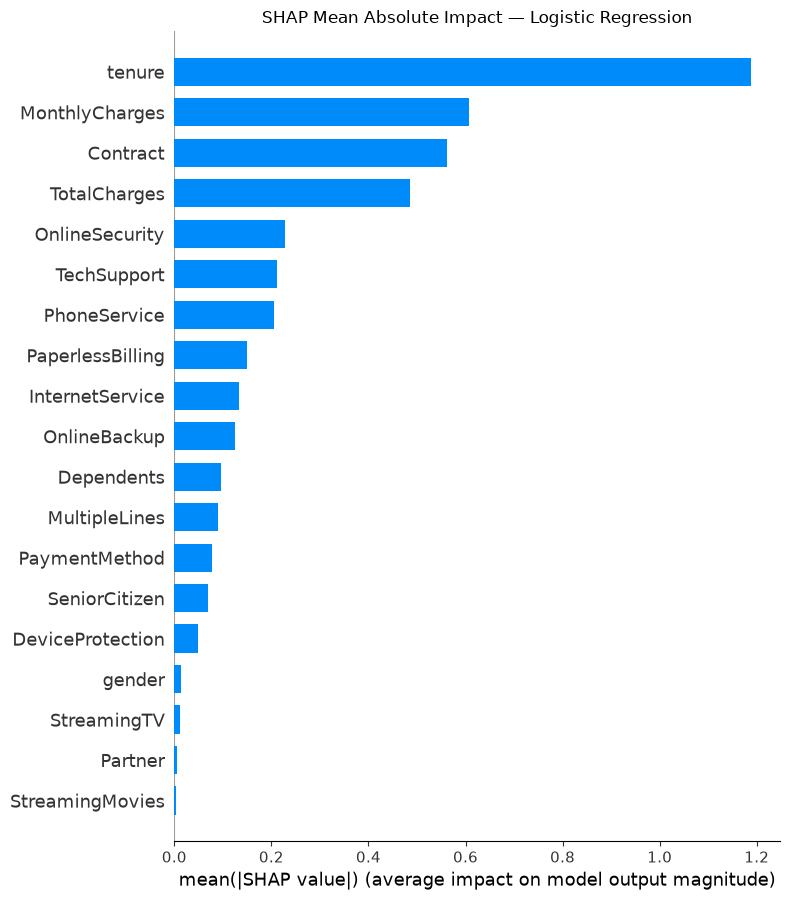

In [9]:
plt.figure()
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP Mean Absolute Impact — Logistic Regression")
plt.tight_layout()
plt.savefig('../data/shap_bar_lr.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Save SHAP values and explainers
np.save('../data/shap_values_xgb.npy', shap_values_xgb)
np.save('../data/shap_values_lr.npy',  shap_values_lr)

joblib.dump(explainer_xgb, '../models/explainer_xgb.pkl')
joblib.dump(explainer_lr,  '../models/explainer_lr.pkl')

print("SHAP values and explainers saved ✓")

SHAP values and explainers saved ✓
